# Question 1 — Fiabilité des jugements humains
## Exercice 1.1 — Accord sur le signal « creative »

### Note structurelle importante sur les données

Dans compar:IA, chaque `conversation_pair_id` correspond à **une session unique d'un seul utilisateur** qui interagit simultanément avec deux modèles. Pour un `(conversation_pair_id, msg_index)` donné, **le même utilisateur** a réagi aux deux réponses (position A et position B).

Il n'existe **aucun cas** où deux utilisateurs différents ont annoté le même message (confirmé empiriquement : chaque `(conversation_pair_id, msg_index, refers_to_model)` a exactement 1 `visitor_id` unique).


**Approche retenue** : mesurer la **consistance intra-paire**. C'est à dire que pour un même contexte conversationnel, l'utilisateur est-il cohérent dans ses labels `creative` entre la réponse du modèle A et celle du modèle B ? Ce signal mesure la fiabilité du label créativité : un label fiable serait discriminant (l'utilisateur labellise une réponse comme créative et l'autre non), tandis qu'un label bruité produirait des patterns aléatoires.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('../data/4ffc86e1-84a4-4fdc-9726-66408e596fef')
print(f"Total reactions: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Total reactions: 91,833
Columns: ['id', 'timestamp', 'model_a_name', 'model_b_name', 'refers_to_model', 'msg_index', 'opening_msg', 'conversation_a', 'conversation_b', 'model_pos', 'conv_turns', 'conversation_pair_id', 'conv_a_id', 'conv_b_id', 'refers_to_conv_id', 'session_hash', 'visitor_id', 'response_content', 'question_content', 'liked', 'disliked', 'comment', 'useful', 'creative', 'complete', 'clear_formatting', 'incorrect', 'superficial', 'instructions_not_followed', 'model_pair_name', 'msg_rank', 'question_id', 'system_prompt']


## Exploration du signal `creative`

In [2]:
# Distribution du label creative
print("Distribution du label 'creative':")
print(df['creative'].value_counts(dropna=False))
print(f"\nTaux de label creative=True: {df['creative'].eq(True).mean():.2%}")
print(f"Valeurs None/NaN: {df['creative'].isna().sum() + df['creative'].eq(None).sum()}")

Distribution du label 'creative':
creative
False    85151
True      6166
None       516
Name: count, dtype: int64

Taux de label creative=True: 6.71%
Valeurs None/NaN: 516


In [4]:
# Structure des paires : chaque (conv_pair_id, msg_index) a-t-il 1 ou 2 réactions ?
pair_counts = df.groupby(['conversation_pair_id', 'msg_index']).size()
print("Nombre de réactions par (conversation_pair_id, msg_index):")
print(pair_counts.value_counts())
print(f"\nPaires avec exactement 2 réactions (A+B): {(pair_counts == 2).sum():,}")
print(f"Paires avec 1 seule réaction: {(pair_counts == 1).sum():,}")

# Vérification: ces 2 réactions proviennent-elles du même utilisateur ?
same_visitor = df.groupby(['conversation_pair_id', 'msg_index'])['visitor_id'].nunique()
print(f"\nNombre unique de visitor_id par paire: {same_visitor.value_counts().to_dict()}")
print("chaque paire n'a qu'un seul annotateur (même utilisateur, 2 modèles)")

Nombre de réactions par (conversation_pair_id, msg_index):
2    31868
1    28097
Name: count, dtype: int64

Paires avec exactement 2 réactions (A+B): 31,868
Paires avec 1 seule réaction: 28,097

Nombre unique de visitor_id par paire: {1: 59965}
chaque paire n'a qu'un seul annotateur (même utilisateur, 2 modèles)


## Construction du dataset d'accord

On pivote les données pour obtenir, pour chaque `(conversation_pair_id, msg_index)` avec 2 réactions, le label `creative` attribué à la position A et à la position B par le même utilisateur.

In [5]:
# Convertir creative en booléen (None = False)
df['creative_bool'] = df['creative'].eq(True)
df['useful_bool'] = df['useful'].eq(True)
df['complete_bool'] = df['complete'].eq(True)

# Garder uniquement les paires avec exactement 2 réactions 
pairs_with_2 = df.groupby(['conversation_pair_id', 'msg_index']).filter(
    lambda x: len(x) == 2 and set(x['model_pos']) == {'a', 'b'}
)
print(f"Réactions dans des paires complètes (a+b): {len(pairs_with_2):,}")
print(f"Nombre de paires complètes: {len(pairs_with_2) // 2:,}")

Réactions dans des paires complètes (a+b): 63,736
Nombre de paires complètes: 31,868


In [6]:
# Pivot : une ligne par paire, colonnes = labels pour position a et b
def build_pivot(data, label_col):
    pivot = data.pivot_table(
        index=['conversation_pair_id', 'msg_index'],
        columns='model_pos',
        values=label_col,
        aggfunc='first'
    ).rename(columns={'a': 'label_a', 'b': 'label_b'})
    return pivot.dropna()

pivot_creative = build_pivot(pairs_with_2, 'creative_bool')
pivot_useful   = build_pivot(pairs_with_2, 'useful_bool')
pivot_complete = build_pivot(pairs_with_2, 'complete_bool')

print(f"Paires pour creative: {len(pivot_creative):,}")
print(f"Paires pour useful:   {len(pivot_useful):,}")
print(f"Paires pour complete: {len(pivot_complete):,}")

Paires pour creative: 31,868
Paires pour useful:   31,868
Paires pour complete: 31,868


## 1. Taux d'accord brut

In [7]:
def raw_agreement(pivot):
    return (pivot['label_a'] == pivot['label_b']).mean()

agr_creative = raw_agreement(pivot_creative)
agr_useful   = raw_agreement(pivot_useful)
agr_complete = raw_agreement(pivot_complete)

print("=== Taux d'accord brut ===")
print(f"creative : {agr_creative:.3f} ({agr_creative:.1%})")
print(f"useful   : {agr_useful:.3f} ({agr_useful:.1%})")
print(f"complete : {agr_complete:.3f} ({agr_complete:.1%})")

=== Taux d'accord brut ===
creative : 0.906 (90.6%)
useful   : 0.742 (74.2%)
complete : 0.752 (75.2%)


In [8]:
# Table de contingence pour creative
ct = pd.crosstab(
    pivot_creative['label_a'].map({True: 'creative_a=True', False: 'creative_a=False'}),
    pivot_creative['label_b'].map({True: 'creative_b=True', False: 'creative_b=False'}),
    margins=True
)
print("Table de contingence : creative (positions A vs B):")
print(ct)

Table de contingence : creative (positions A vs B):
label_b           creative_b=False  creative_b=True    All
label_a                                                   
creative_a=False             28387             1527  29914
creative_a=True               1464              490   1954
All                          29851             2017  31868


## 2. κ de Cohen

Le κ de Cohen corrige l'accord brut par la probabilité d'accord par hasard :

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

| κ | Interprétation (Landis & Koch, 1977) |
|---|---|
| < 0 | Désaccord |
| 0.00–0.20 | Accord quasi nul |
| 0.21–0.40 | Accord faible |
| 0.41–0.60 | Accord modéré |
| 0.61–0.80 | Accord substantiel |
| 0.81–1.00 | Accord presque parfait |

In [10]:
def cohen_kappa(pivot):
    y1 = pivot['label_a'].astype(int).values
    y2 = pivot['label_b'].astype(int).values
    return cohen_kappa_score(y1, y2)

kappa_creative = cohen_kappa(pivot_creative)
kappa_useful   = cohen_kappa(pivot_useful)
kappa_complete = cohen_kappa(pivot_complete)

def interpret_kappa(k):
    if k < 0:    return "désaccord"
    if k < 0.20: return "quasi nul"
    if k < 0.40: return "faible"
    if k < 0.60: return "modéré"
    if k < 0.80: return "substantiel"
    return "presque parfait"

print("kappa de Cohen")
for label, kappa in [('creative', kappa_creative), ('useful', kappa_useful), ('complete', kappa_complete)]:
    print(f"{label:<10}: κ = {kappa:.4f}  =>  {interpret_kappa(kappa)}")

kappa de Cohen
creative  : κ = 0.1968  =>  quasi nul
useful    : κ = 0.3032  =>  faible
complete  : κ = 0.1316  =>  quasi nul


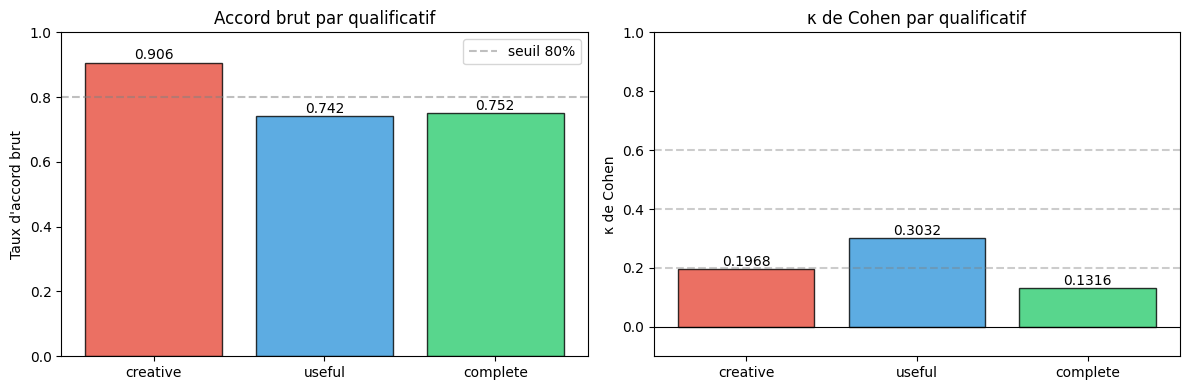

In [11]:
# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

labels = ['creative', 'useful', 'complete']
raw_agrs = [agr_creative, agr_useful, agr_complete]
kappas = [kappa_creative, kappa_useful, kappa_complete]
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars1 = ax1.bar(labels, raw_agrs, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Taux d\'accord brut')
ax1.set_title('Accord brut par qualificatif')
ax1.set_ylim(0, 1)
ax1.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='seuil 80%')
for bar, val in zip(bars1, raw_agrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center')
ax1.legend()

bars2 = ax2.bar(labels, kappas, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('κ de Cohen')
ax2.set_title('κ de Cohen par qualificatif')
ax2.set_ylim(-0.1, 1)
ax2.axhline(0, color='black', linewidth=0.8)
for thresh, label in [(0.20, 'faible'), (0.40, 'modéré'), (0.60, 'substantiel')]:
    ax2.axhline(thresh, color='gray', linestyle='--', alpha=0.4)
for bar, val in zip(bars2, kappas):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.savefig('results/ex1_1_kappa_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pourquoi `creative` est plus bruité que `useful`

**Hypothèse 1 — Subjectivité intrinsèque du concept de créativité**  
La créativité est un concept multidimensionnel (nouveauté, valeur, surprise) sans définition opérationnelle partagée. Deux utilisateurs (ou le même utilisateur face à deux réponses dans un contexte différent) peuvent appliquer des critères implicites incompatibles (stylistique vs. conceptuelle vs. originalité thématique). L'utilité, en revanche, est directement vérifiable par rapport au besoin exprimé dans la question.

**Hypothèse 2 — Base rate très faible de `creative=True` (∼7%)**  
Le taux de labellisation créative est beaucoup plus faible que le taux d'utilité. Avec un signal rare, le label est plus sensible au contexte, à l'humeur de l'utilisateur et aux effets de contraste (une réponse semble créative seulement relative à l'autre). Un utilisateur peut labelliser A comme créative et ne pas penser à labelliser B, introduisant une asymétrie non informative. L'utilité, plus fréquemment activée, bénéficie d'un ancrage sémantique plus stable.

In [12]:
# Résumé des résultats
results = pd.DataFrame({
    'qualificatif': ['creative', 'useful', 'complete'],
    'n_paires': [len(pivot_creative), len(pivot_useful), len(pivot_complete)],
    'base_rate_a': [
        pivot_creative['label_a'].mean(),
        pivot_useful['label_a'].mean(),
        pivot_complete['label_a'].mean()
    ],
    'accord_brut': [agr_creative, agr_useful, agr_complete],
    'kappa': [kappa_creative, kappa_useful, kappa_complete],
    'interpretation': [interpret_kappa(k) for k in [kappa_creative, kappa_useful, kappa_complete]]
})

print("Résultats Exercice 1.1: ")
print(results.to_string(index=False))
results.to_csv('results/ex1_1_results.csv', index=False)

Résultats Exercice 1.1: 
qualificatif  n_paires  base_rate_a  accord_brut    kappa interpretation
    creative     31868     0.061315     0.906144 0.196757      quasi nul
      useful     31868     0.244665     0.741653 0.303171         faible
    complete     31868     0.171457     0.751757 0.131630      quasi nul


L'accord brut de 90,6% pour creative est trompeur. En effet, le signal creative n'est activé que dans 6,1% des cas. Donc, même un annotateur qui dirait systématiquement "non" attendrait un bon score d'accord.  
Le kappa permet de corriger cet effet en soustrayant l'effet du hasard.  
Ici, on remarque que tous les kappas sont faibles (voire quasi nuls), le label creative est donc fortement aléatoire.  

---
## Exercice 1.2 — Biais de sélection des votants


In [13]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Charger seulement les colonnes utiles (évite de lire 3.4GB en entier)
CONV_PATH  = '../data/9dd3d51f-4299-4193-ab46-81ae039fe1be'
VOTES_PATH = '../data/7651fd0b-f222-43b3-8db8-ed6ae660d313'

cols_conv = ['conversation_pair_id', 'conv_turns', 'categories',
             'total_conv_a_output_tokens', 'total_conv_b_output_tokens']

df_conv  = pq.read_table(CONV_PATH,  columns=cols_conv).to_pandas()
df_votes = pq.read_table(VOTES_PATH, columns=['conversation_pair_id']).to_pandas()

voted_ids = set(df_votes['conversation_pair_id'].unique())
df_conv['has_vote'] = df_conv['conversation_pair_id'].isin(voted_ids)

print(f"Total conversations : {len(df_conv):,}")
print(f"Avec vote           : {df_conv['has_vote'].sum():,} ({df_conv['has_vote'].mean():.1%})")
print(f"Sans vote           : {(~df_conv['has_vote']).sum():,}")

Total conversations : 481,109
Avec vote           : 148,844 (30.9%)
Sans vote           : 332,265


### 1. Distribution de `conv_turns`

In [14]:
voted   = df_conv[df_conv['has_vote']]
nonvoted = df_conv[~df_conv['has_vote']]

print("conv_turns — avec vote:")
print(voted['conv_turns'].describe())
print("\nconv_turns — sans vote:")
print(nonvoted['conv_turns'].describe())

ks_stat, ks_p = stats.ks_2samp(voted['conv_turns'], nonvoted['conv_turns'])
print(f"\nTest KS conv_turns: stat={ks_stat:.4f}, p={ks_p:.2e}")
print(f"% multi-turn votées    : {(voted['conv_turns'] > 1).mean():.1%}")
print(f"% multi-turn non-votées: {(nonvoted['conv_turns'] > 1).mean():.1%}")

conv_turns — avec vote:
count    148844.000000
mean          1.343884
std           1.205512
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         140.000000
Name: conv_turns, dtype: float64

conv_turns — sans vote:
count    332265.000000
mean          1.353110
std           1.849847
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         152.000000
Name: conv_turns, dtype: float64

Test KS conv_turns: stat=0.1549, p=0.00e+00
% multi-turn votées    : 18.2%
% multi-turn non-votées: 20.5%


Total output tokens

In [17]:
df_conv['total_output_tokens'] = (
    df_conv['total_conv_a_output_tokens'] + df_conv['total_conv_b_output_tokens']
)

# Recréer voted/nonvoted maintenant que la colonne existe
voted    = df_conv[df_conv['has_vote']]
nonvoted = df_conv[~df_conv['has_vote']]

print("total_output_tokens — avec vote:")
print(voted['total_output_tokens'].describe())
print("\ntotal_output_tokens — sans vote:")
print(nonvoted['total_output_tokens'].describe())

ks_tok, ks_tok_p = stats.ks_2samp(voted['total_output_tokens'], nonvoted['total_output_tokens'])
print(f"\nTest KS output tokens: stat={ks_tok:.4f}, p={ks_tok_p:.2e}")

total_output_tokens — avec vote:
count    148844.000000
mean       2037.689386
std        2179.886102
min           0.000000
25%         915.000000
50%        1543.000000
75%        2508.000000
max      158047.000000
Name: total_output_tokens, dtype: float64

total_output_tokens — sans vote:
count    332265.000000
mean       1886.725243
std        3377.477143
min           0.000000
25%         226.000000
50%        1114.000000
75%        2260.000000
max      149571.000000
Name: total_output_tokens, dtype: float64

Test KS output tokens: stat=0.2098, p=0.00e+00


### 2. Distribution des catégories (`selected_category`)

In [18]:
# categories est une liste, on explode pour obtenir une ligne par catégorie
voted_cats   = voted[['conversation_pair_id','categories']].explode('categories')
nonvoted_cats = nonvoted[['conversation_pair_id','categories']].explode('categories')

# Fréquence relative par catégorie dans chaque groupe
freq_voted    = voted_cats['categories'].value_counts(normalize=True)
freq_nonvoted = nonvoted_cats['categories'].value_counts(normalize=True)

cat_df = pd.DataFrame({
    'voted': freq_voted,
    'nonvoted': freq_nonvoted
}).dropna().sort_values('voted', ascending=False).head(15)

cat_df['ratio'] = cat_df['voted'] / cat_df['nonvoted']  # >1 = sur-représentée dans les votes

print("Top catégories — sur/sous-représentation dans les votes vs non-votées:")
print(cat_df.to_string())

Top catégories — sur/sous-représentation dans les votes vs non-votées:
                                                    voted  nonvoted     ratio
categories                                                                   
Natural Science & Formal Science & Technology    0.179898  0.166387  1.081202
Education                                        0.149582  0.138618  1.079092
Business & Economics & Finance                   0.084345  0.097102  0.868629
Society & Social Issues & Human Rights           0.073111  0.066246  1.103629
Politics & Government                            0.067867  0.059476  1.141075
Entertainment & Travel & Hobby                   0.067722  0.085908  0.788310
Culture & Cultural geography                     0.060977  0.049792  1.224624
Arts                                             0.048515  0.046547  1.042272
Environment                                      0.040130  0.028283  1.418846
Personal Development & Human Resources & Career  0.037668  0.043912  0.

### 3. Visualisations

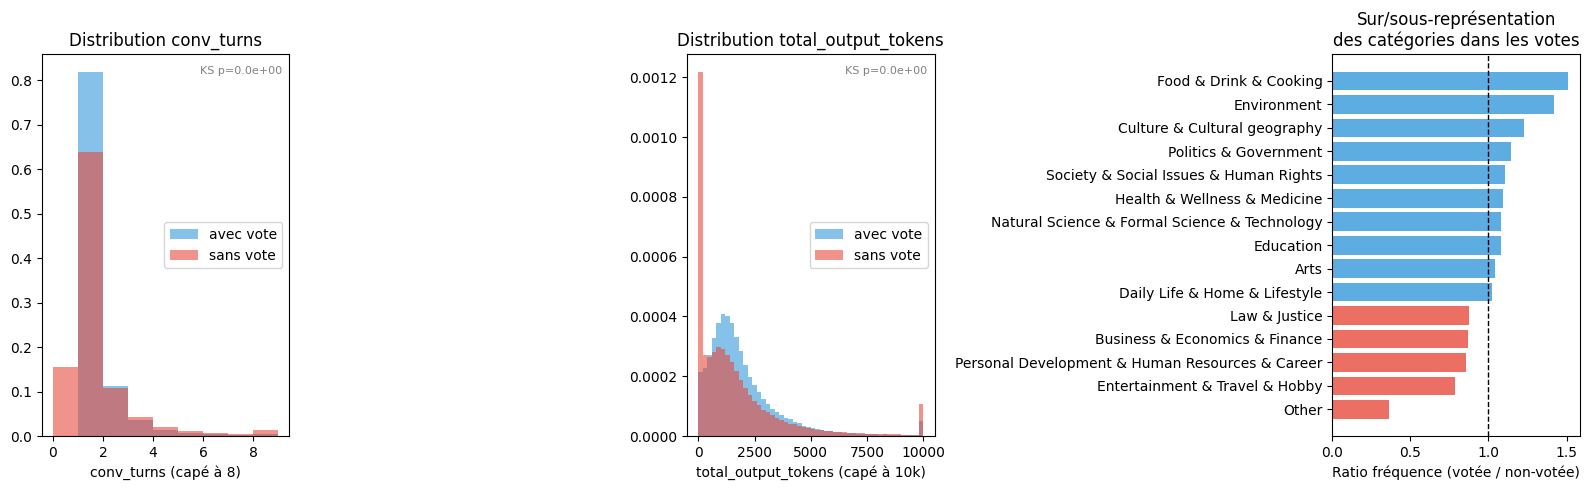

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# conv_turns (cap à 8)
cap = 8
axes[0].hist(voted['conv_turns'].clip(upper=cap),    bins=range(cap+2), density=True,
             alpha=0.6, label='avec vote',  color='#3498db')
axes[0].hist(nonvoted['conv_turns'].clip(upper=cap), bins=range(cap+2), density=True,
             alpha=0.6, label='sans vote',  color='#e74c3c')
axes[0].set_xlabel('conv_turns (capé à 8)')
axes[0].set_title('Distribution conv_turns')
axes[0].legend()
axes[0].text(0.97, 0.97, f'KS p={ks_p:.1e}', transform=axes[0].transAxes,
             ha='right', va='top', fontsize=8, color='gray')

# output_tokens (log scale, cap à 10k)
cap_tok = 10000
axes[1].hist(voted['total_output_tokens'].clip(upper=cap_tok),    bins=50, density=True,
             alpha=0.6, label='avec vote',  color='#3498db')
axes[1].hist(nonvoted['total_output_tokens'].clip(upper=cap_tok), bins=50, density=True,
             alpha=0.6, label='sans vote',  color='#e74c3c')
axes[1].set_xlabel('total_output_tokens (capé à 10k)')
axes[1].set_title('Distribution total_output_tokens')
axes[1].legend()
axes[1].text(0.97, 0.97, f'KS p={ks_tok_p:.1e}', transform=axes[1].transAxes,
             ha='right', va='top', fontsize=8, color='gray')

# Ratio voted/nonvoted par catégorie
cat_df_sorted = cat_df.sort_values('ratio')
colors = ['#e74c3c' if r < 1 else '#3498db' for r in cat_df_sorted['ratio']]
axes[2].barh(cat_df_sorted.index, cat_df_sorted['ratio'], color=colors, alpha=0.8)
axes[2].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[2].set_xlabel('Ratio fréquence (votée / non-votée)')
axes[2].set_title('Sur/sous-représentation\ndes catégories dans les votes')

plt.tight_layout()
plt.savefig('results/ex1_2_selection_bias.png', dpi=150, bbox_inches='tight')
plt.show()



### 4. Résumé

In [21]:
summary = pd.DataFrame({
    'groupe': ['avec vote', 'sans vote'],
    'n': [len(voted), len(nonvoted)],
    'conv_turns_median': [voted['conv_turns'].median(), nonvoted['conv_turns'].median()],
    'conv_turns_mean':   [voted['conv_turns'].mean(),   nonvoted['conv_turns'].mean()],
    'pct_multi_turn':    [(voted['conv_turns'] > 1).mean(), (nonvoted['conv_turns'] > 1).mean()],
    'output_tokens_median': [voted['total_output_tokens'].median(), nonvoted['total_output_tokens'].median()],
    'output_tokens_mean':   [voted['total_output_tokens'].mean(),   nonvoted['total_output_tokens'].mean()],
})
print("Résumé Exercice 1.2:")
print(summary.to_string(index=False))
summary.to_csv('results/ex1_2_results.csv', index=False)

Résumé Exercice 1.2:
   groupe      n  conv_turns_median  conv_turns_mean  pct_multi_turn  output_tokens_median  output_tokens_mean
avec vote 148844                1.0         1.343884        0.181707                1543.0         2037.689386
sans vote 332265                1.0         1.353110        0.204882                1114.0         1886.725243


### 4. Implications pour la généralisabilité des classements

**Résumé des biais observés :**

1) conv_turns : biais faible mais néanmoins significatif  
  
Les distributions sont statistiquement différentes (KS p≈0), mais l'effet est limité en pratique : médiane identique (1 tour dans les deux cas), et l'écart sur le taux multi-turn est faible (18.2% vs 20.5%). Les conversations non-votées ont une variance plus élevée (std 1.85 vs 1.21), avec des queues plus longues (max 152 vs 140). Ce sont les très longues conversations qui échappent le plus aux votes.

Implication : marginale sur conv_turns. Le biais de sélection ne vient pas principalement de là.

2) total_output_tokens : biais de longueur clair 
  
Les conversations votées sont systématiquement plus longues : médiane 1543 tokens vs 1114 (soit +38%), moyenne +8%. Surtout, la distribution des non-votées est bien plus étalée (std 3377 vs 2179) avec un 25e percentile très bas (226 tokens) — beaucoup de conversations très courtes ne reçoivent pas de vote.

Implication : les modèles qui produisent des réponses courtes sont sous-représentés dans les votes. Un classement Bradley-Terry sur les votes favorise structurellement les modèles verbeux, indépendamment de leur qualité réelle. 

3) Catégories ; biais de sélection thématique  
  
Les sur-représentées dans les votes (ratio > 1) :

Food & Drink (ratio 1.51), Environment (1.42), Culture (1.22), Politics (1.14) — ce sont des sujets où les utilisateurs ont un avis tranché et sont donc plus enclins à voter.  
  
Les sous-représentées (ratio < 1) :

Other (0.36) — catégorie fourre-tout, probablement des requêtes techniques ponctuelles sans engagement fort.
Entertainment & Travel (0.79), Business & Economics (0.87) — sujets plus utilitaires, usage plus transactionnel.  

Le point critique pour la créativité : Arts n'est que légèrement sur-représentée (1.04), tandis que Culture l'est davantage (1.22). Les catégories où les utilisateurs labellisent le plus creative (stories, ideas absentes de ce top, donc peu fréquentes globalement) sont précisément celles qui biaisent le signal créatif.

4) Implication générales  
  
Les 30.9% de conversations votées ne sont pas un échantillon représentatif du corpus. Elles sur-représentent les sujets engageants et les réponses longues, et sous-représentent les usages transactionnels courts. Un classement Bradley-Terry construit sur ces votes mesure la performance des modèles sur un sous-ensemble biaisé. Il sera plus fiable pour les tâches de fond (science, culture, politique) que pour les usages rapides (Other, Business). Tout classement de créativité amplifie ce biais, car le signal creative est encore plus concentré sur quelques catégories.